# Analiza danych - Telco Customer Churn

W tym notebooku robie podstawowe EDA dla cech numerycznych, wybieram 5 najciekawszych zaleznosci i pokazuje je na wykresach.

Zbior danych: `WA_Fn-UseC_-Telco-Customer-Churn.csv`.


In [1]:

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from constants import CHURN, DATA_FILE, MONTHLY_CHARGES, SENIOR_CITIZEN, TENURE, TOTAL_CHARGES

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Plik z danymi:", DATA_FILE)


Plik z danymi: resources\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [ ]:
data = pd.read_csv(DATA_FILE)

numeric_columns = [TENURE, MONTHLY_CHARGES, TOTAL_CHARGES, SENIOR_CITIZEN]
for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")
    

def numeric_statistics(df: pd.DataFrame) -> pd.DataFrame:
    numeric_data = df[numeric_columns]

    statistics = pd.DataFrame(
        {
            "srednia": numeric_data.mean(),
            "mediana": numeric_data.median(),
            "min": numeric_data.min(),
            "max": numeric_data.max(),
            "odchylenie_standardowe": numeric_data.std(),
        }
    )

    return pd.DataFrame(statistics.round(2))


print("Pierwsze 5 wierszy:")
display(data.head())

print("Informacje o kolumnach:")
data.info()

print("Podstawowe statystyki dla cech numerycznych z pandas:")
display(data[numeric_columns].describe().round(2))

print("podstawowe obliczone ręcznie statystkiki dla cech numerycznych")
display(numeric_statistics(data))



Pierwsze 5 wierszy:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Informacje o kolumnach:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  

""


Podstawowe statystyki dla cech numerycznych z pandas:


,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
count,7043.00,7043.00,7032.00,7043.00
mean,32.37,64.76,2283.30,0.16
std,24.56,30.09,2266.77,0.37
min,0.00,18.25,18.80,0.00
25%,9.00,35.50,401.45,0.00
50%,29.00,70.35,1397.48,0.00
75%,55.00,89.85,3794.74,0.00
max,72.00,118.75,8684.80,1.00


podstawowe obliczone ręcznie statystkiki dla cech numerycznych


,srednia,mediana,min,max,odchylenie_standardowe
tenure,32.37,29.00,0.00,72.00,24.56
MonthlyCharges,64.76,70.35,18.25,118.75,30.09
TotalCharges,2283.30,1397.48,18.80,8684.80,2266.77
SeniorCitizen,0.16,0.00,0.00,1.00,0.37


In [3]:
def tenure_histogram(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=TENURE, bins=20, color="skyblue", edgecolor="black")
    plt.title("Histogram: czas trwania umowy")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def tenure_churn_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=TENURE)
    plt.title("Boxplot: czas trwania umowy wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("czas trwania umowy")
    plt.tight_layout()
    plt.show()


def monthly_charges_histogram(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df, x=MONTHLY_CHARGES, bins=20, color="orange", edgecolor="black")
    plt.title("Histogram: miesieczna oplata")
    plt.xlabel("miesieczna oplata")
    plt.ylabel("Liczba klientow")
    plt.tight_layout()
    plt.show()


def monthly_charges_churn_boxplot(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x=CHURN, y=MONTHLY_CHARGES)
    plt.title("Boxplot: miesieczna oplata wzgledem rezygnacji")
    plt.xlabel("Rezygnacja")
    plt.ylabel("miesieczna oplata")
    plt.tight_layout()
    plt.show()


def tenure_monthly_charges_scatter(df: pd.DataFrame) -> None:
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x=TENURE, y=MONTHLY_CHARGES, hue=CHURN, alpha=0.7)
    plt.title("Wykres rozrzutu: czas trwania umowy i miesieczna oplata")
    plt.xlabel("czas trwania umowy")
    plt.ylabel("miesieczna oplata")
    plt.legend(title="Rezygnacja")
    plt.tight_layout()
    plt.show()


## Dlaczego te 5 wykresow

- `tenure` - pokazuje, jak dlugo klient korzysta z uslug. Nowi klienci zwykle czesciej rezygnuja.
- `MonthlyCharges` - pokazuje miesieczny koszt uslug. Wysoka oplata moze zwiekszac ryzyko odejscia.
- `tenure` vs `Churn` - pozwala sprawdzic, czy klienci odchodzacy maja krotszy czas korzystania z uslug.
- `MonthlyCharges` vs `Churn` - pokazuje, czy osoby odchodzace placa wiecej niz pozostali klienci.
- `tenure` vs `MonthlyCharges` - pozwala zobaczyc zaleznosc miedzy dlugoscia umowy i wysokoscia oplat.


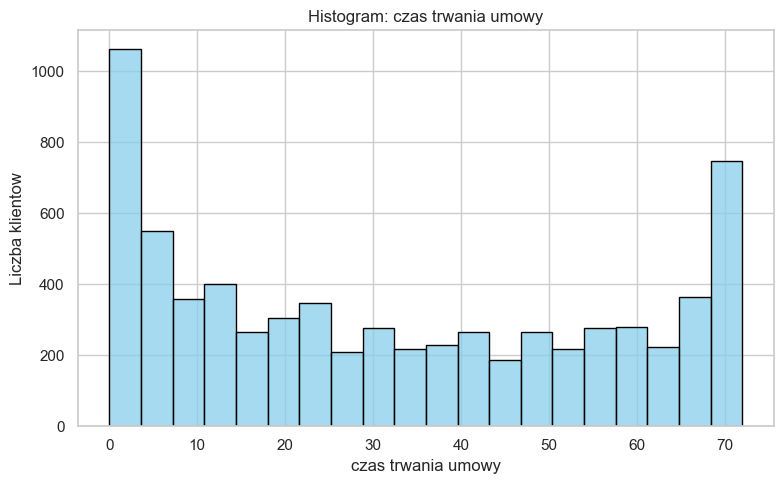

In [4]:
tenure_histogram(data)


Histogram wykazuje rozkład bimodalny. Najliczniejsze grupy stanowią nowi klienci (0-5 miesięcy) oraz klienci długoterminowi (powyżej 65 miesięcy).


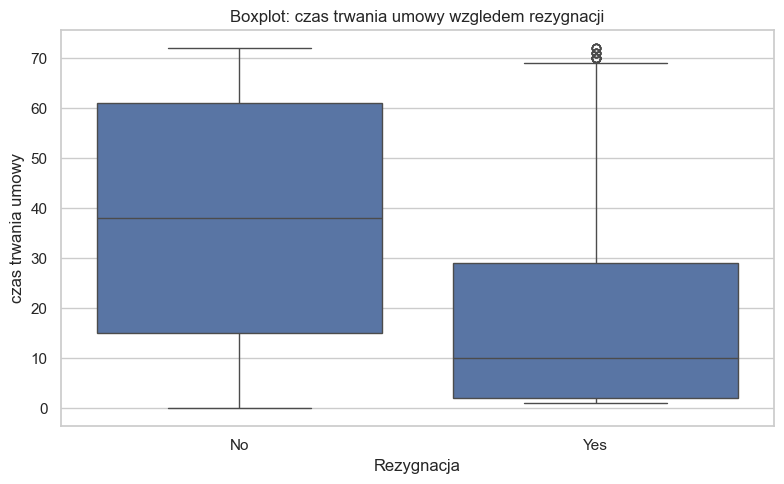

In [5]:
tenure_churn_boxplot(data)


Mediana stażu umowy dla osób rezygnujących (ok. 10 mies.) jest drastycznie niższa niż dla osób pozostających (ok. 38 mies.). 75% wszystkich odejść następuje przed upływem 30 miesiąca trwania umowy.

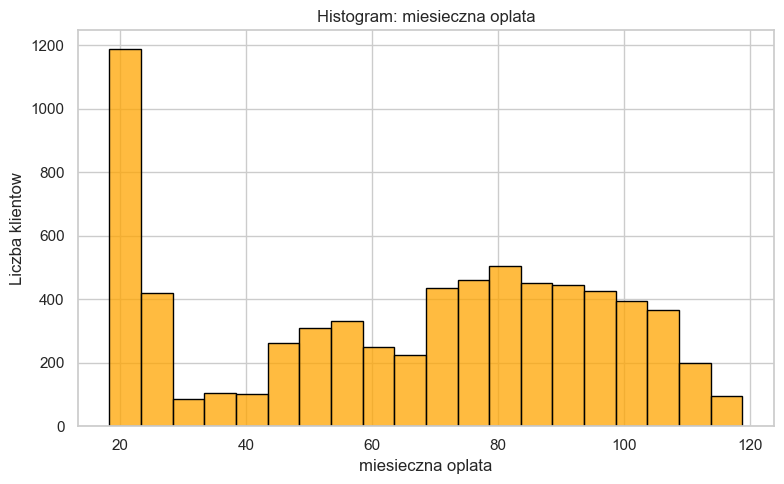

In [6]:
monthly_charges_histogram(data)


 Wyraźna segmentacja klientów na dwie grupy: "Low-tier" (opłaty ok. 20 zł) oraz "High-tier" (opłaty 70-100 zł) Bardzo mała liczebność segmentu średniego (40-60 zł).
 

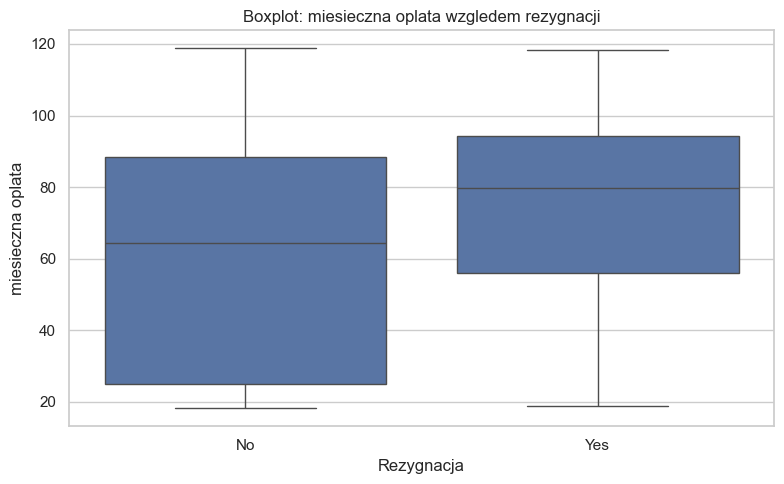

In [7]:
monthly_charges_churn_boxplot(data)


Klienci rezygnujący płacą średnio o ok. 25% wyższe stawki miesięczne niż klienci lojalni (mediana ok. 80 zł vs 65 zł).

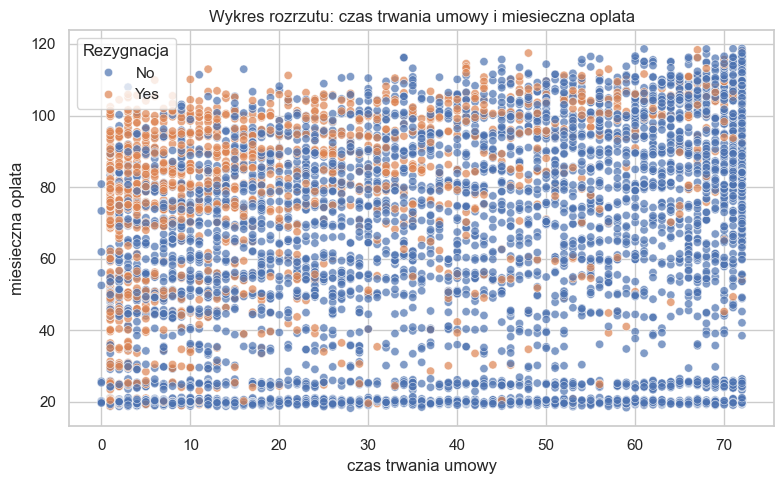

In [8]:
tenure_monthly_charges_scatter(data)


Największa gęstość rezygnacji (punkty pomarańczowe) występuje w obszarze krótkiego stażu i wysokich opłat (lewy górny róg wykresu).

## wniosek

Najbardziej obiecujace cechy to `tenure` (czas trwania umowy) i `MonthlyCharges` (opłaty miesięczne), bo bezposrednio pokazuja, jak dlugo klient zostaje i ile placi. To zwykle pomaga zrozumiec, kto ma wieksze ryzyko rezygnacji.
